In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff
import cv2
from deepcell.applications import Mesmer
from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay 

from skimage.measure import regionprops
from skimage.measure import approximate_polygon
import os
import pandas as pd

2025-06-26 10:22:46.328287: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/ext_sharon_wariko_astraeabio_com/anaconda3/envs/astreabio/lib/python3.9/site-packages/cv2/../../lib64:
2025-06-26 10:22:46.328312: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
path_to_imc_cores_orig = "/mnt/disks/ext_hd/chiba/data/Chiba_folder_from_Trevor/IMC_First_set/Chiba_ome-tiff"
#path_to_imc_cores_orig = '/home/shamini/data2/projects/chiba_pathomics/data/Chiba_folder_from_Trevor/IMC_First_set/Chiba_ome-tiff/'
#path_to_imc_cores_same = '/home/shamini/data2/projects/chiba_pathomics/data/Chiba_folder_from_Trevor/IMC_Same_ometiff/'

In [3]:
channels = [30, 
            9, 
            10, 
            11, 
            12, 
            13, 
            14, 
            15, 
            16, 
            17, 
            18, 
            19, 
            20, 
            21, 
            22, 
            23, 
            24, 
            25, 
            26, 
            27, 
            28, 
            29, 
            32, 
            33, 
            34]

markers = ['DNA', 'VIMENTIN', 'EGFR', 'GFAP', 
           'NEUN', 'CD163', 'MAP2', 
           'O4', 'CD45', 'CD4', 
           'E-CAD', 'CD68', 'CD8A', 
           'CX3CR1', 'CCK', 'ARGINASE1', 
           'CD34', 'KI67', 'IBA1', 
           'CD3', 'H3', 'P2Y12', 
            'ICSK1', 'ICSK2', 'ICSK3']

In [4]:
out_root = '/mnt/disks/ext_hd/chiba/data/Chiba_folder_from_Trevor/IMC_First_set/Chiba_ome-tiff/'
os.makedirs(out_root, exist_ok=True)

In [5]:
os.listdir(path_to_imc_cores_orig)

['ROI9_GBM4-Core.ome.tiff',
 'ROI38_GBM6-Edge.ome.tiff',
 'ROI5_GBM5-Edge.ome.tiff',
 'ROI35_AA1-Core.ome.tiff',
 'ROI3_Control 2.ome.tiff',
 'ROI33_GBM1-Core.ome.tiff',
 'ROI20_Oligo 3-Core.ome.tiff',
 'ROI6_GBM10-Edge.ome.tiff',
 'ROI10_GBM9-Core.ome.tiff',
 'ROI39_AA1-Edge.ome.tiff',
 'script01_imc_protein_expression',
 'ROI8_Oligo 5-Edge.ome.tiff',
 'ROI15_AA4-Edge.ome.tiff',
 'ROI2_GBM10-Core.ome.tiff',
 'ROI36_Oligo 1-Core.ome.tiff',
 'ROI25_GBM2-Core.ome.tiff',
 'ROI23_AA3-Edge.ome.tiff',
 'ROI29_GBM2-Edge.ome.tiff',
 'ROI13_GBM4-Edge.ome.tiff',
 'ROI18_GBM8-Core.ome.tiff',
 'ROI22_GBM8-Edge.ome.tiff',
 'ROI27_AA2-Core.ome.tiff',
 'script01_imc_cell_info',
 'ROI7_Control 1.ome.tiff',
 'ROI30_GBM7-Edge.ome.tiff',
 'ROI16_Oligo 4-Edge.ome.tiff',
 'ROI34_GBM6-Core.ome.tiff',
 'ROI1_GBM5-Core.ome.tiff',
 'ROI40_Oligo 1-Edge.ome.tiff',
 'script01_imc_polygon_img_coords',
 'ROI26_GBM7-Core.ome.tiff',
 'ROI24_Oligo 3-Edge.ome.tiff',
 'ROI17_GBM3-Core.ome.tiff',
 'ROI12_Oligo 4-Core.ome

In [6]:
core_names = os.listdir(path_to_imc_cores_orig)

os.makedirs(os.path.join(out_root, 'script01_imc_protein_expression'), exist_ok=True)
os.makedirs(os.path.join(out_root, 'script01_imc_cell_info'), exist_ok=True)
os.makedirs(os.path.join(out_root, 'script01_imc_polygon_img_coords'), exist_ok=True)

protein_expression_out_path = os.path.join(out_root, 'script01_imc_protein_expression')
df_cell_out_path = os.path.join(out_root, 'script01_imc_cell_info')
polygons_img_coord_out_path = os.path.join(out_root, 'script01_imc_polygon_img_coords')


In [7]:

# Function to sort coordinates in counter-clockwise order
def order_vertices(coords):
    # Calculate the centroid
    centroid = np.mean(coords, axis=0)
    
    # Calculate the angle of each point relative to the centroid
    angles = np.arctan2(coords[:, 1] - centroid[1], coords[:, 0] - centroid[0])
    
    # Sort the coordinates by angle
    ordered_coords = coords[np.argsort(angles)]
    
    return ordered_coords

In [8]:
images_orig = []
for core in core_names:
    if not core.lower().endswith(".tiff"):
        continue

    img = os.path.join(path_to_imc_cores_orig +'/'+ core)
    try:
        img = tiff.imread(img)
    
        print(f'Intitial shape of image: {img.shape}')
        img = img[channels, :, :]
        print(f'Shape of image after selecting channels: {img.shape}')
    
        images_orig.append(img)
    except Exception as e:
        print(f"Failed to load {core}:{e}")


Intitial shape of image: (36, 914, 967)
Shape of image after selecting channels: (25, 914, 967)
Intitial shape of image: (36, 1268, 1010)
Shape of image after selecting channels: (25, 1268, 1010)
Intitial shape of image: (36, 1000, 1000)
Shape of image after selecting channels: (25, 1000, 1000)
Intitial shape of image: (36, 1037, 1016)
Shape of image after selecting channels: (25, 1037, 1016)
Intitial shape of image: (36, 991, 965)
Shape of image after selecting channels: (25, 991, 965)
Intitial shape of image: (36, 1057, 1011)
Shape of image after selecting channels: (25, 1057, 1011)
Intitial shape of image: (36, 1074, 1000)
Shape of image after selecting channels: (25, 1074, 1000)
Intitial shape of image: (36, 1075, 1048)
Shape of image after selecting channels: (25, 1075, 1048)
Intitial shape of image: (36, 1010, 983)
Shape of image after selecting channels: (25, 1010, 983)
Intitial shape of image: (36, 1048, 1048)
Shape of image after selecting channels: (25, 1048, 1048)
Intitial s

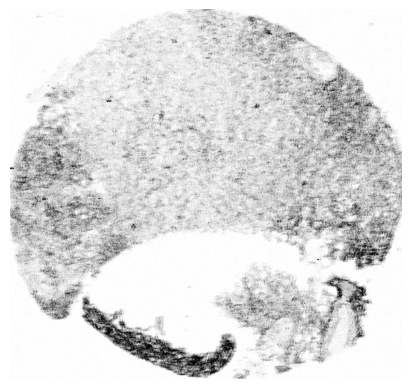

In [9]:

image_to_segment = images_orig[0][[0,22,23,24],:,:]
cyto_combined = np.zeros((image_to_segment.shape[1], image_to_segment.shape[2]), dtype=image_to_segment.dtype)

for i in range(3):
    upper_quantile = np.quantile(image_to_segment[i+1,:,:], 0.995)
    clipped_image = np.clip(image_to_segment[i+1,:,:], 0, upper_quantile)
    ### normalized clipped image
    norm_image = cv2.normalize(clipped_image, None, 0, 255, cv2.NORM_MINMAX)
    cyto_combined_orig = np.maximum(cyto_combined, norm_image)
    
plt.imshow(cyto_combined_orig, cmap='gray_r')
plt.axis('off')

del images_orig

In [ ]:
for core in core_names:
    if not core.lower().endswith(".tiff"):
        continue

    img_path = os.path.join(path_to_imc_cores_orig, core)

    try:
        img = tiff.imread(img_path)
        print(f'Initial shape of image: {img.shape}')
        img = img[channels, :, :]
        print(f'Shape of image after selecting channels: {img.shape}')

        # Cytoplasmic segmentation
        image_to_segment = img[[0, 22, 23, 24], :, :]
        cyto_combined = np.zeros((image_to_segment.shape[1], image_to_segment.shape[2]), dtype=image_to_segment.dtype)

        for i in range(3):  # using channels 22, 23, 24 (3 channels)
            upper_quantile = np.quantile(image_to_segment[i + 1, :, :], 0.995)
            clipped_image = np.clip(image_to_segment[i + 1, :, :], 0, upper_quantile)
            norm_image = cv2.normalize(clipped_image, None, 0, 255, cv2.NORM_MINMAX)
            cyto_combined = np.maximum(cyto_combined, norm_image)

        dapi_cyto = np.zeros((2, image_to_segment.shape[1], image_to_segment.shape[2]), dtype=image_to_segment.dtype)
        dapi = image_to_segment[0, :, :]

        upper_quantile = np.quantile(dapi, 0.999)
        clipped_image = np.clip(dapi, 0, upper_quantile)
        norm_image = cv2.normalize(clipped_image, None, 0, 255, cv2.NORM_MINMAX)

        dapi_cyto[0, :, :] = norm_image
        dapi_cyto[1, :, :] = cyto_combined

        dapi_cyto = np.moveaxis(dapi_cyto, 0, -1)
        dapi_cyto = np.expand_dims(dapi_cyto, axis=0)

        app = Mesmer()
        labeled_img = app.predict(dapi_cyto, compartment='both')
        rgb_image = create_rgb_image(dapi_cyto, channel_colors=['blue', 'green'])
        overlay_data = make_outline_overlay(rgb_image, labeled_img)

        name = core.split(".")[0]
        protein_expression_filepath = os.path.join(protein_expression_out_path, f'{name}_protein_expression.csv')
        df_cell_filepath = os.path.join(df_cell_out_path, f'{name}_cell_info.csv')
        polygons_img_coord_filepath = os.path.join(polygons_img_coord_out_path, f'{name}_polygons_img_coord.csv')

        polygons_img_coord = pd.DataFrame()
        df_cell = pd.DataFrame()
        protein_mtx = pd.DataFrame()

        whole_cell_image = labeled_img[0, :, :, 0]
        nuclei_image = labeled_img[0, :, :, 1]

        whole_cell_props = regionprops(whole_cell_image)

        for prop in whole_cell_props:
            coords = prop.coords
            coords = approximate_polygon(coords, tolerance=0.1)
            coords = np.vstack([coords, coords[0]])  # close the polygon
            coords = order_vertices(coords)
            df = pd.DataFrame(coords)
            df['cell_id'] = prop.label

            polygons_img_coord = pd.concat([polygons_img_coord, df], axis=0)

            cell_info = pd.DataFrame({
                'cell_id': prop.label,
                'centroid_x': prop.centroid[0],
                'centroid_y': prop.centroid[1],
                'area': prop.area
            }, index=[0])

            df_cell = pd.concat([df_cell, cell_info], axis=0)

            mask = whole_cell_image == prop.label
            protein_row = {'cell_id': prop.label}

            for i in range(25):
                image = img[i, :, :]
                upper_quantile = np.quantile(image, 0.999)
                clipped_image = np.clip(image, 0, upper_quantile)
                norm_image = cv2.normalize(clipped_image, None, 0, 255, cv2.NORM_MINMAX)
                expression = np.sum(norm_image[mask])
                protein_row[markers[i]] = expression

            protein_mtx = pd.concat([protein_mtx, pd.DataFrame([protein_row])], axis=0)

        polygons_img_coord.columns = ['x', 'y', 'cell_id']
        protein_mtx.to_csv(protein_expression_filepath, index=False)
        df_cell.to_csv(df_cell_filepath, index=False)
        polygons_img_coord.to_csv(polygons_img_coord_filepath, index=False)

    except Exception as e:
        print(f"❌ Error processing {core}: {e}")

Initial shape of image: (36, 914, 967)
Shape of image after selecting channels: (25, 914, 967)


2025-06-26 10:38:00.075158: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/ext_sharon_wariko_astraeabio_com/anaconda3/envs/astreabio/lib/python3.9/site-packages/cv2/../../lib64:
2025-06-26 10:38:00.075187: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2025-06-26 10:38:00.075200: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (chiba-project-vm): /proc/driver/nvidia/version does not exist
2025-06-26 10:38:00.076195: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the

Initial shape of image: (36, 1268, 1010)
Shape of image after selecting channels: (25, 1268, 1010)
Initial shape of image: (36, 1000, 1000)
Shape of image after selecting channels: (25, 1000, 1000)
Initial shape of image: (36, 1037, 1016)
Shape of image after selecting channels: (25, 1037, 1016)
Initial shape of image: (36, 991, 965)
Shape of image after selecting channels: (25, 991, 965)
Initial shape of image: (36, 1057, 1011)
Shape of image after selecting channels: (25, 1057, 1011)
Initial shape of image: (36, 1074, 1000)
Shape of image after selecting channels: (25, 1074, 1000)
Initial shape of image: (36, 1075, 1048)
Shape of image after selecting channels: (25, 1075, 1048)
Initial shape of image: (36, 1010, 983)
Shape of image after selecting channels: (25, 1010, 983)
Initial shape of image: (36, 1048, 1048)
Shape of image after selecting channels: (25, 1048, 1048)
Initial shape of image: (36, 1021, 877)
Shape of image after selecting channels: (25, 1021, 877)
Initial shape of i

---